## Working with the `TexTable` class

The `TexTable` class is intended to be a user-friendly way to generate and preview 
nice tables in latex. Currenly, the class only supports working with pandas dataframes,
and while pandas does profide a `to_latex` function, it has limited functionaity and is
more troublesome to modify. The `TexTable` class intends to be more flexible and to alleviate
the majority of the most troublesome things that come with generating a latex table.


> NOTE: Usage of the `preview` function of the `TexTable` class does require a latex compiler be 
> installed on the machine that you are working from.

### Basic construction

The `TexTable` class comes with a basic previewer and some default settings that are intended to 
turn most data tables into a nice format

- All columns are "c" aligned
- Columns headers are bolded
- There is a double "\hline" under the header
- Numbers are rounded to 4 decimal places

\begin{tabular}{cccccc}
\textbf{Column 1} & \textbf{Column 2} & \textbf{Column 3} & \textbf{Column 4} & \textbf{Column 5} & \textbf{Names} \\
\hline\hline
0.8027 & 0.3215 & 0.3691 & 0.3149 & 0.8049 & item 0 \\
0.2398 & 0.5861 & 0.5191 & 0.5089 & 0.7054 & item 1 \\
0.4979 & 0.1471 & 0.8834 & 0.3553 & 0.1660 & item 2 \\
NaN & 0.6562 & 0.5879 & 0.7544 & 0.4327 & item 3 \\
0.5902 & 0.0399 & 0.0644 & 0.1932 & 0.4936 & item 4 \\
0.8490 & 0.3838 & 0.3894 & 0.7346 & 0.2392 & item 5 \\
0.9783 & 0.5327 & 0.5279 & 0.4478 & 0.9666 & item 6 \\
0.9031 & 0.5931 & 0.0255 & 0.3382 & 0.3546 & item 7 \\
0.9105 & 0.0098 & 0.3721 & 0.5014 & 0.4537 & item 8 \\
0.5755 & 0.1347 & 0.6448 & 0.5590 & 0.9247 & item 9 \\
\end{tabular}


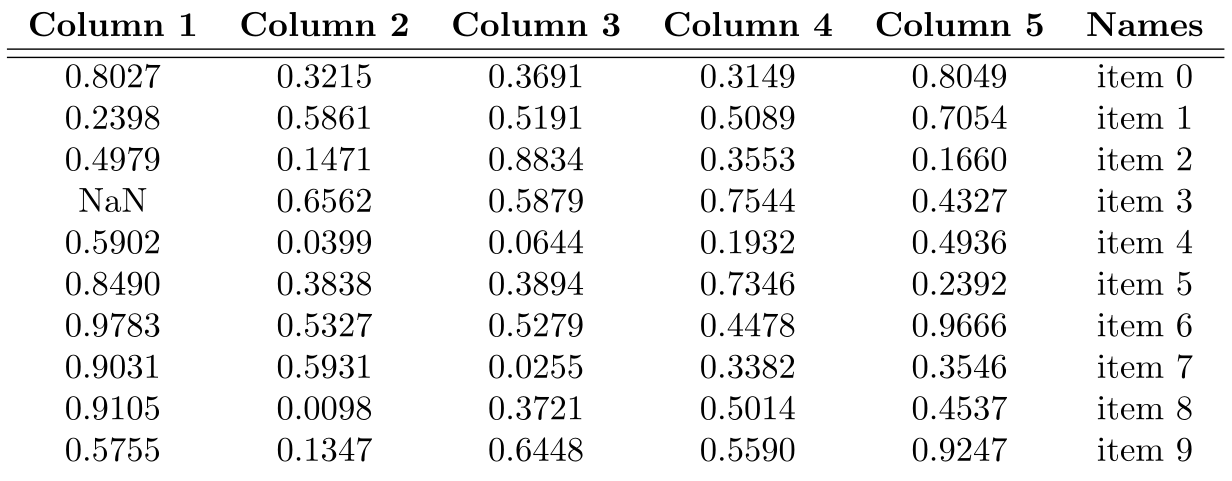

\documentclass[border=2pt]{standalone}
\usepackage{amsmath}
\usepackage{amssymb}
\usepackage{graphicx}
\usepackage{booktabs}
\usepackage{array}
\usepackage{latexcolors}
\usepackage{siunitx}
\usepackage{xfp}
\usepackage{colortbl}
\definecolor{snsgreen}{rgb}{0.16,0.51,0.25}
\definecolor{snspurple}{rgb}{0.50,0.24,0.55}
\begin{document}
\begin{tabular}{cccccc}
\textbf{Column 1} & \textbf{Column 2} & \textbf{Column 3} & \textbf{Column 4} & \textbf{Column 5} & \textbf{Names} \\
\hline\hline
0.8027 & 0.3215 & 0.3691 & 0.3149 & 0.8049 & item 0 \\
0.2398 & 0.5861 & 0.5191 & 0.5089 & 0.7054 & item 1 \\
0.4979 & 0.1471 & 0.8834 & 0.3553 & 0.1660 & item 2 \\
NaN & 0.6562 & 0.5879 & 0.7544 & 0.4327 & item 3 \\
0.5902 & 0.0399 & 0.0644 & 0.1932 & 0.4936 & item 4 \\
0.8490 & 0.3838 & 0.3894 & 0.7346 & 0.2392 & item 5 \\
0.9783 & 0.5327 & 0.5279 & 0.4478 & 0.9666 & item 6 \\
0.9031 & 0.5931 & 0.0255 & 0.3382 & 0.3546 & item 7 \\
0.9105 & 0.0098 & 0.3721 & 0.5014 & 0.4537 & item 8 \\
0.5755 & 0.1347 & 

In [1]:
from gerrytools.latex import TexTable
import numpy as np
import pandas as pd

matrix = [
    [0.80271163743772220, 0.321512174755157140, 0.369115226617589200, 0.31491956081869720, 0.80485545809736710, 'item 0'],
    [0.23978517293553825, 0.586115829039532600, 0.519058426662538300, 0.50887366708748860, 0.70538884840360450, 'item 1'],
    [0.49788093635713690, 0.147094584046825300, 0.883437964402974700, 0.35533523957545940, 0.16596946781954303, 'item 2'],
    [np.nan,              0.656233021634028100, 0.587913583766714500, 0.75440208936075340, 0.43268492945683945, 'item 3'],
    [0.59018769659385240, 0.039858169085697170, 0.064420904621522830, 0.19322895452079558, 0.49364239553622780, 'item 4'],
    [0.84900033328055560, 0.383806911314474300, 0.389438471897368000, 0.73455238166505020, 0.23924648233550140, 'item 5'],
    [0.97830650055081290, 0.532739901197703800, 0.527858349264338400, 0.44780991717414830, 0.96662006080425280, 'item 6'],
    [0.90307272545248380, 0.593075079923604100, 0.025498235068052155, 0.33815336977092236, 0.35462742657985113, 'item 7'],
    [0.91046016100649210, 0.009761192390978168, 0.372096054027488130, 0.50135080530420410, 0.45370604145037685, 'item 8'],
    [0.57550701776487460, 0.134713703285684330, 0.644751736450971700, 0.55899830218616960, 0.92472128347765130, 'item 9']
]


df = pd.DataFrame(matrix, columns=[f"Column {i}" for i in range(1, 6)] + ["Names"])
table = TexTable(df)

print(table)  # Print out the generated LaTeX code 
table.preview()  # Preview the table in either a pop-up window or in the Jupyter notebook
print(table.document) # Print out the full LaTeX document code containing the table

Of course, if you do not like any of these options, you may clear them and start fresh: